In [1]:
import pandas as pd
import seaborn as sns
import ast
import matplotlib.pyplot as plt
import re
import spacy

from wordcloud import WordCloud
from preprocess import transcriptions
from collections import Counter
# python -m spacy download fr_core_news_lg
nlp = spacy.load("fr_core_news_lg")

/opt/python/lib/python3.13/site-packages/torch/cuda/__init__.py:180: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 12090). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0
/home/onyxia/work/Projet-de-NLP/preprocess.py:12: DtypeWarning: Columns (0: departement-nom, 1: departement-insee, 2: identifiant de circonscription, 3: pdf, 4: suppleant-nom, 5: suppleant-prenom, 6: suppleant-sexe, 7: suppleant-age, 8: suppleant-age-calcule, 9: suppleant-age-tranche, 10: suppleant-profession, 11: suppleant-mandat-en-cours, 12: suppleant-mandat-passe, 13: suppleant-associations, 14: suppleant-autres-statuts, 15: suppleant-soutien, 16: 

In [2]:
textes_annotes = pd.read_json("outputs/predictions_tot.jsonl", lines=True)

In [3]:
textes_annotes = textes_annotes.merge(transcriptions[["id", "parti_synthetique"]], on = "id", how="left")
textes_annotes.head()

,id,text,annotations,parti_synthetique
0,EL196_L_1993_03_076_12_1_PF_01,Département de Seine-Maritime - 12ème Circonsc...,"[{'word': 'Département', 'label': 'O', 'score'...",Sans étiquette / Divers
1,EL190_L_1993_03_024_02_1_PF_03,ELECTIONS LEGISLATIVES DU 21 MARS 1993 REPUBLI...,"[{'word': 'ELECTIONS', 'label': 'O', 'score': ...",Sans étiquette / Divers
2,EL190_L_1993_03_017_01_1_PF_07,ELECTIONS LEGISLATIVES MARS 1993 Votre candida...,"[{'word': 'ELECTIONS', 'label': 'O', 'score': ...",Autre / Non classé
3,EL192_L_1993_03_050_02_1_PF_03,ENTENTE DES ECOLOGISTES Elections Législatives...,"[{'word': 'ENTENTE', 'label': 'O', 'score': 0....",Ecologiste
4,EL196_L_1993_03_079_04_1_PF_03,Les Verts Confédération Écologiste - Parti Éco...,"[{'word': 'Les', 'label': 'O', 'score': 0.775,...",Ecologiste


In [4]:
def parse_annotations(val):
    """Accepte une liste Python ou une chaîne repr d'une liste."""
    if isinstance(val, list):
        return val
    if isinstance(val, str):
        try:
            return ast.literal_eval(val)
        except Exception:
            return []
    return []


In [5]:
def extract_entities(annotations, entities_list):
    """
    Renvoie un dict {type_entité: [liste de mots]} pour les tokens B-*.
    On ne garde que les débuts d'entités (B-) pour éviter de double-compter.
    """
    entities = {t: [] for t in entities_list}
    for tok in annotations:
        label = tok.get("label", "O")
        word  = tok.get("word", "")
        if label.startswith("B-"):
            etype = label[2:]
            if etype in entities:
                entities[etype].append(word)
    return entities
 

In [6]:
pronoms_a_exclure = ["me", "m'", "j'", "je", "nous"]
labels_to_clean={'VERB_CONCRET', 'VERB_CONTEXTE'}

def clean_verb(token):
    # Cas : "j'ai", "j'aurais", "j'irai", etc.
    match = re.match(r"^[jJnNlLmMtTsS]'(.+)$", token)
    if match:
        return match.group(1)  # retourne "ai", "aurais", etc.
    return token

def clean_all_entities(df, pron=pronoms_a_exclure, labels_to_clean=labels_to_clean):
    tokens = []
    positions = []
    for idx, entities in enumerate(df['entities']):
        for label, verbs in entities.items():
            if label in labels_to_clean :
                for v in verbs:
                    v_clean = clean_verb(v)
                    if v_clean.lower() not in pron and len(v_clean) > 1:
                        tokens.append(v_clean.lower())
                        positions.append((idx, label))

    # Lemmatisation
    docs = list(nlp.pipe(tokens))
    lemmas = [doc[0].lemma_ for doc in docs]

    result = [{label: verbs for label, verbs in entities.items() if label not in labels_to_clean}
        for entities in df['entities']]
    for (idx, label), lemma in zip(positions, lemmas):
        result[idx].setdefault(label, []).append(lemma)

    df['entities_clean'] = result
    return df

In [7]:
ENTITY_TYPES = ["SUJ", "VERB_CONCRET", "VERB_CONTEXTE", "OBJ"]  

textes_annotes["annotations"] = textes_annotes["annotations"].apply(parse_annotations)
textes_annotes["entities"] = textes_annotes["annotations"].apply(extract_entities, args = [ENTITY_TYPES])
textes_annotes = clean_all_entities(textes_annotes)

In [8]:
for etype in ENTITY_TYPES:
    textes_annotes[f"n_{etype}"] = textes_annotes["entities_clean"].apply(lambda e: len(e.get(etype, [])))
 
textes_annotes["n_tokens_total"] = textes_annotes["entities_clean"].apply(
    lambda e: sum(len(v) for v in e.values()))
textes_annotes["n_entities_total"] = textes_annotes[[f"n_{t}" for t in ENTITY_TYPES]].sum(axis=1)

In [16]:
count_cols = [f"n_{t}" for t in ENTITY_TYPES] + ["n_tokens_total", "n_entities_total"]
ordre_partis = ['Autre / Non classé','Sans étiquette / Divers','Extrême-Gauche', 'Parti socialiste - Gauche', 'Ecologiste',
'Centre', 'UDF/RPR', 'Extrême-Droite', 'Régionaliste']
 
stats = (
    textes_annotes.groupby("parti_synthetique")[count_cols]
    .agg(["sum", "mean", "median", "std"])
)
stats =stats.reset_index()
stats['parti_synthetique'] = pd.Categorical(
    stats['parti_synthetique'], 
    categories=ordre_partis, 
    ordered=True)
stats = stats.sort_values('parti_synthetique')

stats.columns = ["_".join(c) for c in stats.columns]
stats = stats.rename(columns={f"n_tokens_total_count": "n_docs"})

for etype in ENTITY_TYPES:
    stats[f"freq_{etype}"] = (
        stats[f"n_{etype}_sum"] / stats["n_tokens_total_sum"]
    ).round(2)
stats["n_VERB_sum"]=stats["n_VERB_CONCRET_sum"]+stats["n_VERB_CONTEXTE_sum"]
stats["part_VERB"]=stats["n_VERB_sum"]/stats["n_tokens_total_sum"]
stats["part_VERB_CONCRET"] = stats["n_VERB_CONCRET_sum"]/stats["n_VERB_sum"]
stats["part_VERB_CONTEXTE"] = stats["n_VERB_CONTEXTE_sum"]/stats["n_VERB_sum"]
stats.head()

,parti_synthetique_,n_SUJ_sum,n_SUJ_mean,n_SUJ_median,n_SUJ_std,n_VERB_CONCRET_sum,n_VERB_CONCRET_mean,n_VERB_CONCRET_median,n_VERB_CONCRET_std,n_VERB_CONTEXTE_sum,...,n_entities_total_median,n_entities_total_std,freq_SUJ,freq_VERB_CONCRET,freq_VERB_CONTEXTE,freq_OBJ,n_VERB_sum,part_VERB,part_VERB_CONCRET,part_VERB_CONTEXTE
0,Autre / Non classé,1544,5.045752,5.0,5.412602,1453,4.748366,5.0,4.100230,1510,...,15.0,16.112788,0.30,0.28,0.29,0.14,2963,0.567407,0.490381,0.509619
7,Sans étiquette / Divers,7321,5.889783,5.0,4.528839,6535,5.257442,4.0,4.857023,6972,...,17.0,11.883166,0.31,0.27,0.29,0.12,13507,0.567974,0.483823,0.516177
4,Extrême-Gauche,7745,8.135504,6.0,6.036475,4507,4.734244,4.0,3.651450,7963,...,21.0,18.677427,0.29,0.17,0.30,0.24,12470,0.471313,0.361427,0.638573
5,Parti socialiste - Gauche,3620,7.525988,6.0,4.880216,3437,7.145530,6.0,5.491625,3204,...,21.0,13.001339,0.32,0.30,0.28,0.11,6641,0.578031,0.517543,0.482457
2,Ecologiste,2781,2.565498,1.0,2.924149,3304,3.047970,1.0,4.090787,2240,...,4.0,8.957131,0.30,0.36,0.24,0.10,5544,0.598898,0.595960,0.404040


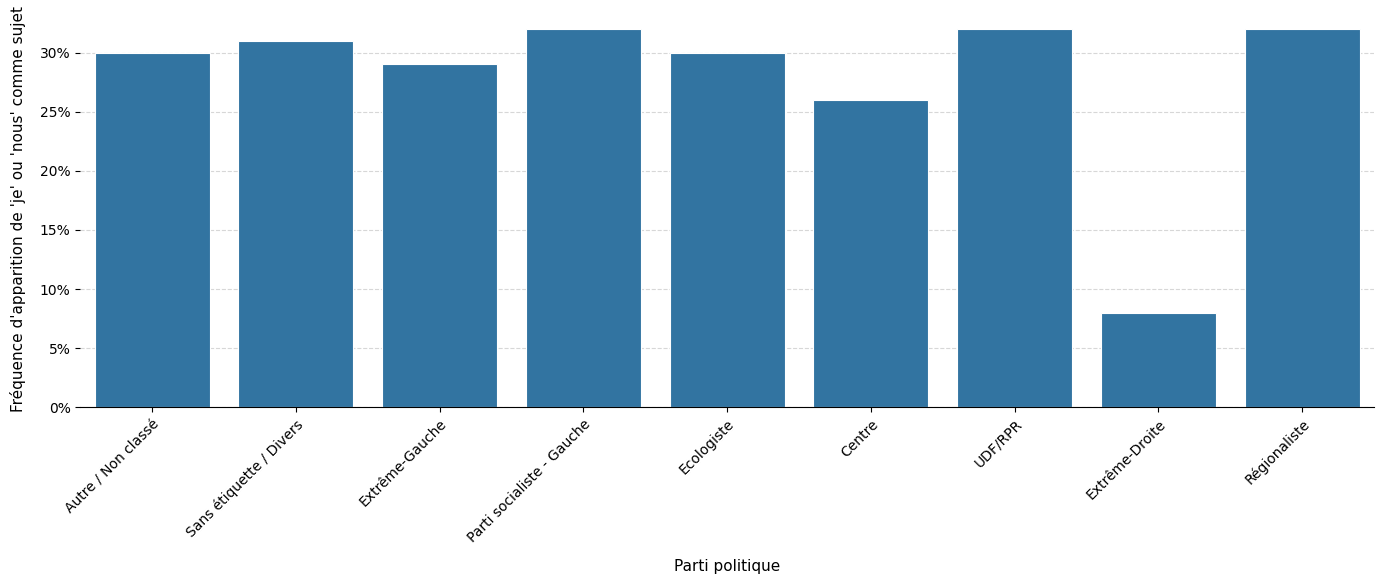

In [10]:
import matplotlib.ticker as mtick

fig, ax = plt.subplots(figsize=(14, 6))

# Thème
sns.set_theme(style="whitegrid", font_scale=1)
palette = sns.color_palette("Blues_d", n_colors=len(stats))


bars = sns.barplot(
    data = stats,
    x = "parti_synthetique_",
    y = "freq_SUJ",
    edgecolor = "white",
    linewidth = 0.8,
    ax = ax
)

ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))

ax.set_xlabel("Parti politique", fontsize=11, labelpad=10)
ax.set_ylabel("Fréquence d'apparition de 'je' ou 'nous' comme sujet", fontsize=11, labelpad=10)

# xticks bien placés et lisibles
ax.set_xticks(range(len(stats)))
ax.set_xticklabels(
    stats["parti_synthetique_"],
    rotation    = 45,
    ha          = "right",      # alignement à droite pour les labels tournés
    rotation_mode = "anchor",   # pivot sur le point d'ancrage → labels bien centrés sous les barres
    fontsize    = 10
)

ax.yaxis.grid(True, linestyle="--", alpha=0.5)
ax.set_axisbelow(True)
ax.spines[["top", "right", "left"]].set_visible(False)

plt.tight_layout()
plt.show()

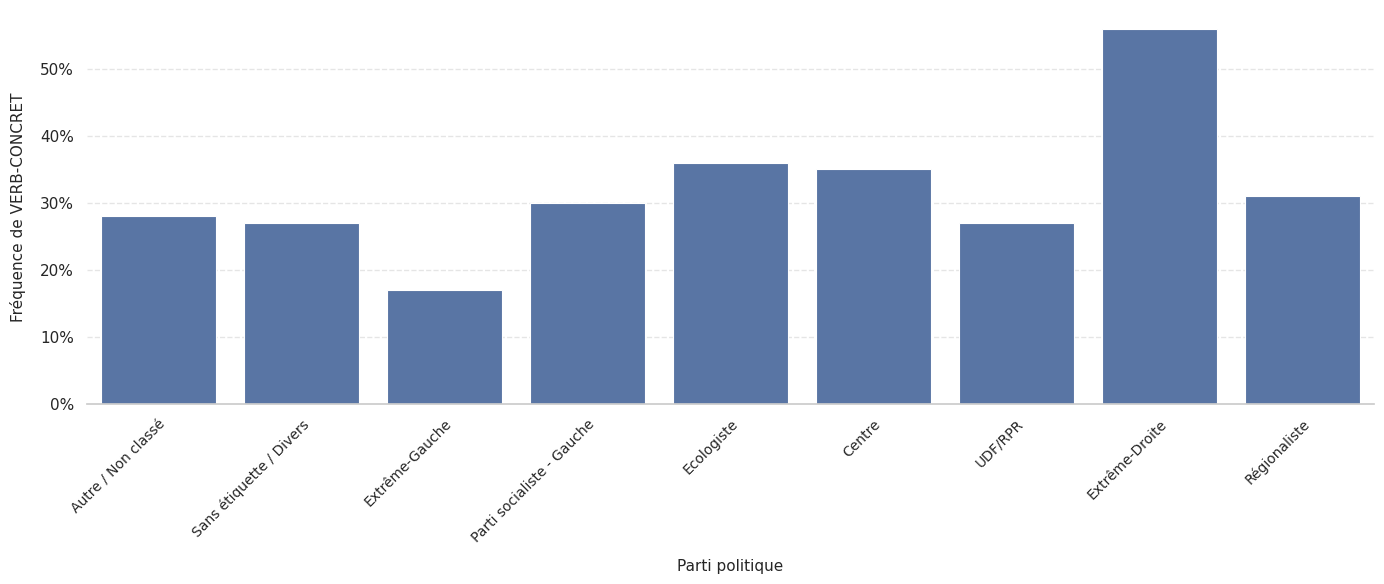

In [11]:
fig, ax = plt.subplots(figsize=(14, 6))

# Thème
sns.set_theme(style="whitegrid", font_scale=1)
palette = sns.color_palette("Blues_d", n_colors=len(stats))


bars = sns.barplot(
    data = stats,
    x = "parti_synthetique_",
    y = "freq_VERB_CONCRET",
    edgecolor = "white",
    linewidth = 0.8,
    ax = ax
)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))

ax.set_xlabel("Parti politique", fontsize=11, labelpad=10)
ax.set_ylabel("Fréquence de VERB-CONCRET", fontsize=11, labelpad=10)

# xticks bien placés et lisibles
ax.set_xticks(range(len(stats)))
ax.set_xticklabels(
    stats["parti_synthetique_"],
    rotation    = 45,
    ha          = "right",      # alignement à droite pour les labels tournés
    rotation_mode = "anchor",   # pivot sur le point d'ancrage → labels bien centrés sous les barres
    fontsize    = 10
)

ax.yaxis.grid(True, linestyle="--", alpha=0.5)
ax.set_axisbelow(True)
ax.spines[["top", "right", "left"]].set_visible(False)

plt.tight_layout()
plt.show()

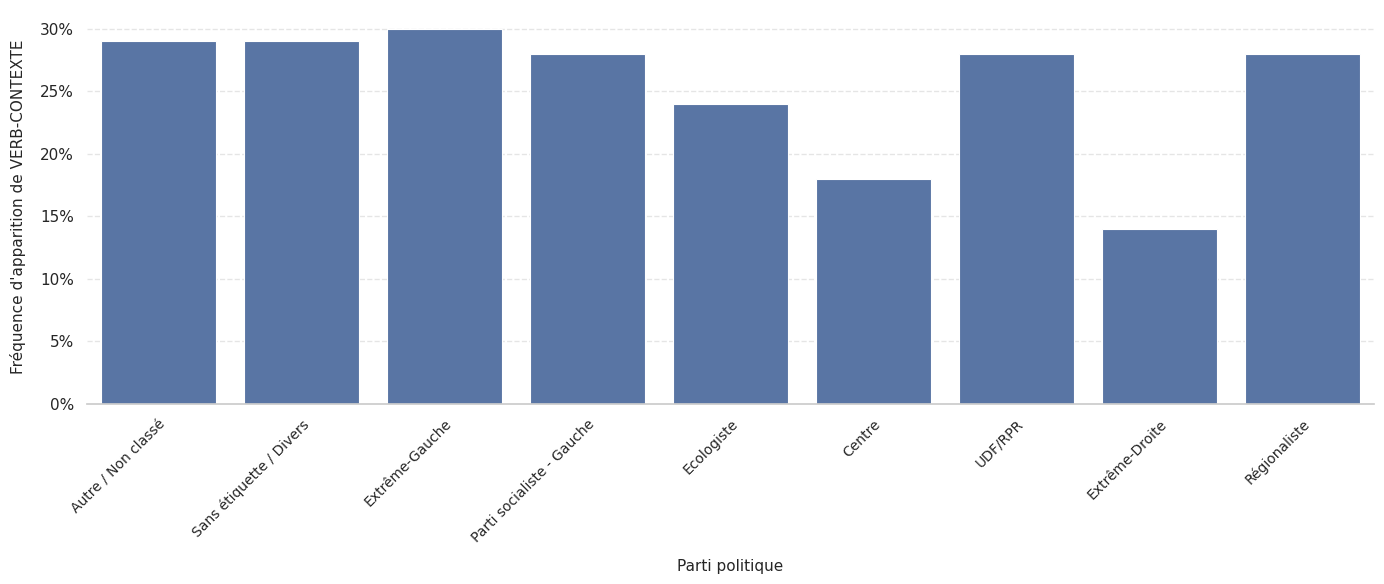

In [12]:
fig, ax = plt.subplots(figsize=(14, 6))

# Thème
sns.set_theme(style="whitegrid", font_scale=1)
palette = sns.color_palette("Blues_d", n_colors=len(stats))


bars = sns.barplot(
    data = stats,
    x = "parti_synthetique_",
    y = "freq_VERB_CONTEXTE",
    edgecolor = "white",
    linewidth = 0.8,
    ax = ax
)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))

ax.set_xlabel("Parti politique", fontsize=11, labelpad=10)
ax.set_ylabel("Fréquence d'apparition de VERB-CONTEXTE", fontsize=11, labelpad=10)

# xticks bien placés et lisibles
ax.set_xticks(range(len(stats)))
ax.set_xticklabels(
    stats["parti_synthetique_"],
    rotation    = 45,
    ha          = "right",      # alignement à droite pour les labels tournés
    rotation_mode = "anchor",   # pivot sur le point d'ancrage → labels bien centrés sous les barres
    fontsize    = 10
)

ax.yaxis.grid(True, linestyle="--", alpha=0.5)
ax.set_axisbelow(True)
ax.spines[["top", "right", "left"]].set_visible(False)

plt.tight_layout()
plt.show()

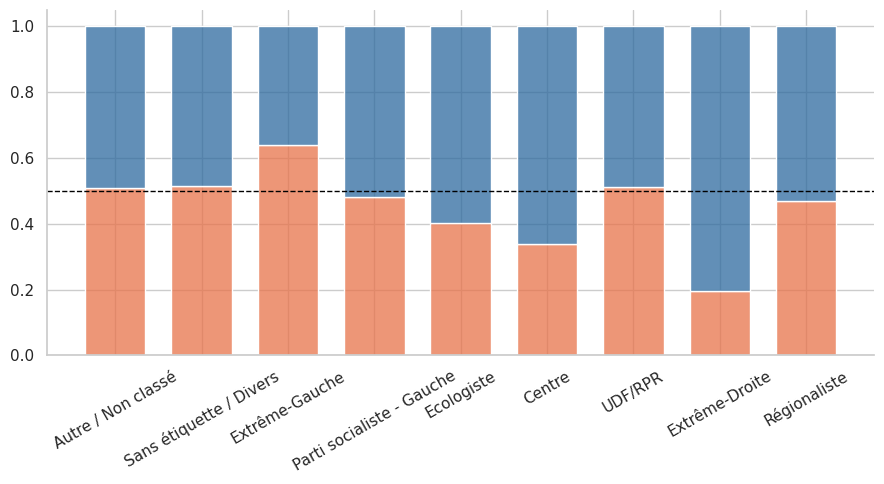

In [13]:
df_long = stats.melt(
    id_vars="parti_synthetique_",
    value_vars=["part_VERB_CONCRET", "part_VERB_CONTEXTE"],
    var_name="type_verbe",
    value_name="part",
)
 
# Barplot empilé
fig, ax = plt.subplots(figsize=(9, 5))
sns.histplot(
    data=df_long,
    x="parti_synthetique_",
    weights="part",
    hue="type_verbe",
    multiple="stack",
    palette=["#2D6A9F", "#E8734A"],
    shrink=0.7,
    ax=ax,
    legend=False
)
ax.axhline(0.5, linestyle="--", color="black", linewidth=1)
ax.set(xlabel="", ylabel="", ylim=(0, 1.05))
ax.tick_params(axis="x", rotation=30)
sns.despine()
plt.tight_layout()

In [14]:
def extract_verbs(annotations, labels):
    """Retourne un dict {label: [verbes]} pour une liste d'annotations."""
    verbs = {label: [] for label in labels}
    for ann in annotations:
        if ann["label"] in labels:
            verbs[ann["label"]].append(ann["label"])
    return verbs

In [18]:
def top5_par_parti_et_categorie(df, labels, n=5):
    results = {}
    for parti, group in df.groupby("parti_synthetique"):
        counts = {label: Counter() for label in labels}
        for entities in group["entities_clean"]:
            for label in labels:
                counts[label].update(entities.get(label, []))
        results[parti] = {label: counts[label].most_common(n) for label in labels}
    return results


def top5_par_parti_global(df, labels, n=5):
    results = {}
    for parti, group in df.groupby("parti_synthetique"):
        counter = Counter()
        for entities in group["entities_clean"]:
            for label in labels:
                counter.update(entities.get(label, []))
        results[parti] = counter.most_common(n)
    return results


def top5_global_par_categorie(df, labels, n=5):
    counts = {label: Counter() for label in labels}
    for entities in df["entities_clean"]:
        for label in labels:
            counts[label].update(entities.get(label, []))
    return {label: counts[label].most_common(n) for label in labels}


def top5_global(df, labels, n=5):
    counter = Counter()
    for entities in df["entities_clean"]:
        for label in labels:
            counter.update(entities.get(label, []))
    return counter.most_common(n)

In [19]:
VB_LABELS =["VERB_CONCRET", "VERB_CONTEXTE"]
print("=" * 60)
print("1) TOP 5 PAR PARTI ET PAR CATÉGORIE")
print("=" * 60)
r1 = top5_par_parti_et_categorie(textes_annotes, VB_LABELS)
for parti, labels in r1.items():
    print(f"\n {parti}")
    for label, top in labels.items():
        print(f"  [{label}]: {top}")

1) TOP 5 PAR PARTI ET PAR CATÉGORIE

 Autre / Non classé
  [VERB_CONCRET]: [('proposer', 146), ('compléter', 125), ('vouloir', 86), ('rendre', 79), ('réussir', 77)]
  [VERB_CONTEXTE]: [('être', 323), ('devoir', 123), ('pouvoir', 105), ('avoir', 103), ('amener', 86)]

 Centre
  [VERB_CONCRET]: [('vouloir', 116), ('exiger', 54), ('souhaiter', 54), ('réclamer', 52), ('faire', 28)]
  [VERB_CONTEXTE]: [('être', 43), ('avoir', 21), ('devoir', 18), ('présenter', 14), ('savoir', 9)]

 Ecologiste
  [VERB_CONCRET]: [('réunir', 393), ('proposer', 216), ('vouloir', 187), ('engager', 136), ('défendre', 74)]
  [VERB_CONTEXTE]: [('désirer', 466), ('être', 337), ('avoir', 109), ('pouvoir', 58), ('vouloir', 47)]

 Extrême-Droite
  [VERB_CONCRET]: [('proteger', 554), ('lutter', 525), ('accorder', 514), ('organiser', 476), ('restaurer', 468)]
  [VERB_CONTEXTE]: [('invite', 480), ('inquiet', 470), ('vouloir', 279), ('être', 67), ('tromper', 61)]

 Extrême-Gauche
  [VERB_CONCRET]: [('faire', 1272), ('défen

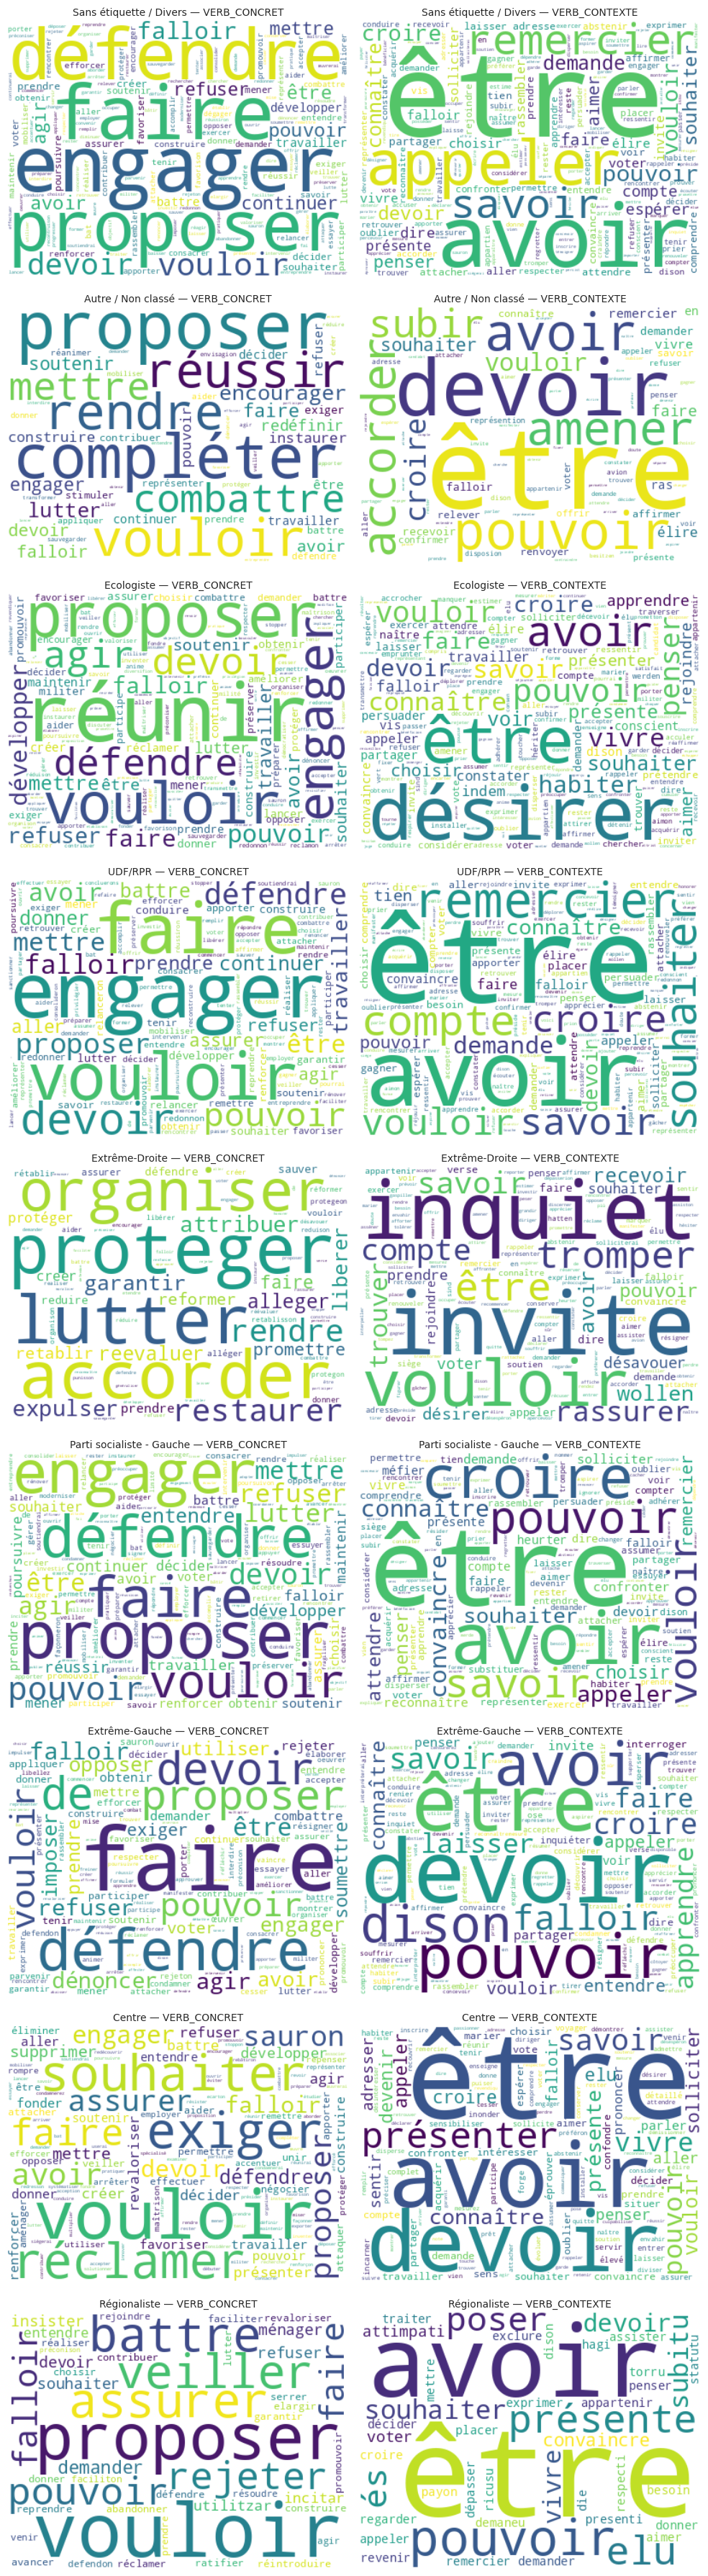

In [20]:
def wordclouds_par_parti_et_categorie(df, labels):
    partis = df["parti_synthetique"].dropna().unique()
    
    fig, axes = plt.subplots(len(partis), len(labels), 
                              figsize=(5 * len(labels), 4 * len(partis)))
    
    for i, parti in enumerate(partis):
        group = df[df["parti_synthetique"] == parti]
        for j, label in enumerate(labels):
            counter = Counter()
            for entities in group["entities_clean"]:
                counter.update(entities.get(label, []))
            
            ax = axes[i][j]
            if counter:
                wc = WordCloud(width=400, height=300, background_color="white")
                wc.generate_from_frequencies(counter)
                ax.imshow(wc, interpolation="bilinear")
            else:
                ax.text(0.5, 0.5, "Aucun verbe", ha="center", va="center")
            
            ax.set_title(f"{parti} — {label}", fontsize=10)
            ax.axis("off")
    
    plt.tight_layout()
    plt.show()

wordclouds_par_parti_et_categorie(textes_annotes, VB_LABELS)

# Partie label_discours

In [22]:
textes_annotes_disc = pd.read_json("outputs/predictions_tot_disc.jsonl", lines=True)
textes_annotes_disc = textes_annotes_disc.merge(transcriptions[["id", "parti_synthetique"]], on = "id", how="left")
textes_annotes_disc.head()

,id,text,annotations,parti_synthetique
0,EL196_L_1993_03_076_12_1_PF_01,Département de Seine-Maritime - 12ème Circonsc...,"[{'word': 'Département', 'label': 'O', 'score'...",Sans étiquette / Divers
1,EL190_L_1993_03_024_02_1_PF_03,ELECTIONS LEGISLATIVES DU 21 MARS 1993 REPUBLI...,"[{'word': 'ELECTIONS', 'label': 'O', 'score': ...",Sans étiquette / Divers
2,EL190_L_1993_03_017_01_1_PF_07,ELECTIONS LEGISLATIVES MARS 1993 Votre candida...,"[{'word': 'ELECTIONS', 'label': 'O', 'score': ...",Autre / Non classé
3,EL192_L_1993_03_050_02_1_PF_03,ENTENTE DES ECOLOGISTES Elections Législatives...,"[{'word': 'ENTENTE', 'label': 'O', 'score': 0....",Ecologiste
4,EL196_L_1993_03_079_04_1_PF_03,Les Verts Confédération Écologiste - Parti Éco...,"[{'word': 'Les', 'label': 'O', 'score': 0.795,...",Ecologiste


In [23]:
ENTITY_TYPES = ["SUJ", "VERB_ACT", "VERB_ETAT", "OBJ"]   

textes_annotes_disc["annotations"] = textes_annotes_disc["annotations"].apply(parse_annotations)
textes_annotes_disc["entities"] = textes_annotes_disc["annotations"].apply(extract_entities, args = [ENTITY_TYPES])
textes_annotes_disc = clean_all_entities(textes_annotes_disc, pron=pronoms_a_exclure ,labels_to_clean={"VERB_ACT", "VERB_ETAT"})

for etype in ENTITY_TYPES:
    textes_annotes_disc[f"n_{etype}"] = textes_annotes_disc["entities_clean"].apply(lambda e, et=etype: len(e.get(et, [])))
 
textes_annotes_disc["n_tokens_total"] = textes_annotes_disc["entities_clean"].apply(
    lambda e: sum(len(v) for v in e.values()))
textes_annotes_disc["n_entities_total"] = textes_annotes_disc[[f"n_{t}" for t in ENTITY_TYPES]].sum(axis=1)

In [24]:
count_cols = [f"n_{t}" for t in ENTITY_TYPES] + ["n_tokens_total", "n_entities_total"]
ordre_partis = ['Autre / Non classé','Sans étiquette / Divers','Extrême-Gauche', 'Parti socialiste - Gauche', 'Ecologiste',
'Centre', 'UDF/RPR', 'Extrême-Droite', 'Régionaliste']
 
stats2 = (
    textes_annotes_disc.groupby("parti_synthetique")[count_cols]
    .agg(["sum", "mean", "median", "std"])
)
stats2 =stats2.reset_index()
stats2['parti_synthetique'] = pd.Categorical(
    stats2['parti_synthetique'], 
    categories=ordre_partis, 
    ordered=True)
stats2 = stats2.sort_values('parti_synthetique')

stats2.columns = ["_".join(c) for c in stats2.columns]
stats2 = stats2.rename(columns={f"n_tokens_total_count": "n_docs"})

for etype in ENTITY_TYPES:
    stats2[f"freq_{etype}"] = (
        stats2[f"n_{etype}_sum"] / stats2["n_tokens_total_sum"]
    ).round(2)
stats2["n_VERB_sum"]=stats2["n_VERB_ACT_sum"]+stats2["n_VERB_ETAT_sum"]
stats2["part_VERB"]=stats2["n_VERB_sum"]/stats2["n_tokens_total_sum"]
stats2["part_VERB_ACT"] = stats2["n_VERB_ACT_sum"]/stats2["n_VERB_sum"]
stats2["part_VERB_ETAT"] = stats2["n_VERB_ETAT_sum"]/stats2["n_VERB_sum"]
stats2.head()

,parti_synthetique_,n_SUJ_sum,n_SUJ_mean,n_SUJ_median,n_SUJ_std,n_VERB_ACT_sum,n_VERB_ACT_mean,n_VERB_ACT_median,n_VERB_ACT_std,n_VERB_ETAT_sum,...,n_entities_total_median,n_entities_total_std,freq_SUJ,freq_VERB_ACT,freq_VERB_ETAT,freq_OBJ,n_VERB_sum,part_VERB,part_VERB_ACT,part_VERB_ETAT
0,Autre / Non classé,1710,5.588235,6.0,5.429765,1741,5.689542,5.0,4.765142,1091,...,16.0,15.865283,0.33,0.34,0.21,0.12,2832,0.546507,0.614760,0.385240
7,Sans étiquette / Divers,7756,6.239743,5.0,4.603835,8354,6.720837,6.0,4.720542,4969,...,17.0,11.791619,0.33,0.35,0.21,0.11,13323,0.559908,0.627036,0.372964
4,Extrême-Gauche,8246,8.661765,7.0,6.316993,7920,8.319328,6.0,5.587552,3752,...,21.0,16.618890,0.33,0.32,0.15,0.21,11672,0.464428,0.678547,0.321453
5,Parti socialiste - Gauche,3884,8.074844,7.0,5.058678,3905,8.118503,7.0,5.061341,2393,...,21.0,12.782794,0.35,0.35,0.21,0.09,6298,0.560669,0.620038,0.379962
2,Ecologiste,3026,2.791513,1.0,3.108218,4315,3.980627,3.0,4.394300,2022,...,6.0,9.281573,0.30,0.42,0.20,0.08,6337,0.620666,0.680922,0.319078


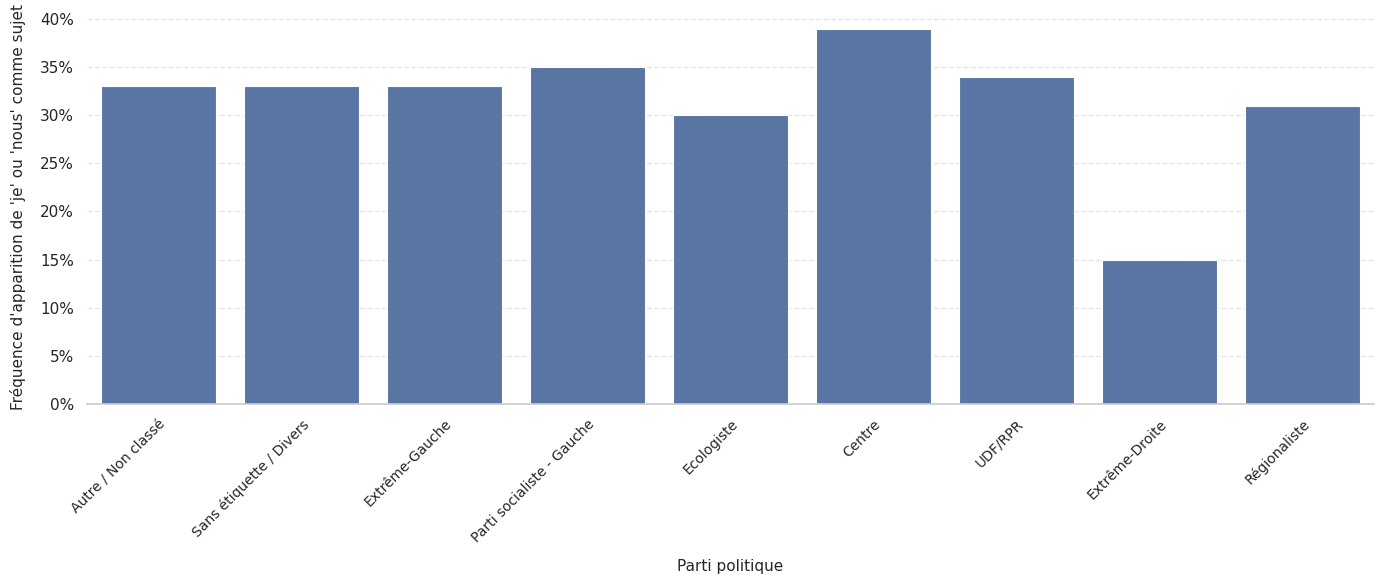

In [37]:
import matplotlib.ticker as mtick

fig, ax = plt.subplots(figsize=(14, 6))

# Thème
sns.set_theme(style="whitegrid", font_scale=1)
palette = sns.color_palette("Blues_d", n_colors=len(stats2))


bars = sns.barplot(
    data = stats2,
    x = "parti_synthetique_",
    y = "freq_SUJ",
    edgecolor = "white",
    linewidth = 0.8,
    ax = ax
)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))

ax.set_xlabel("Parti politique", fontsize=11, labelpad=10)
ax.set_ylabel("Fréquence d'apparition de 'je' ou 'nous' comme sujet", fontsize=11, labelpad=10)

# xticks bien placés et lisibles
ax.set_xticks(range(len(stats2)))
ax.set_xticklabels(
    stats2["parti_synthetique_"],
    rotation = 45,
    ha = "right",      # alignement à droite pour les labels tournés
    rotation_mode = "anchor",   # pivot sur le point d'ancrage → labels bien centrés sous les barres
    fontsize = 10
)

ax.yaxis.grid(True, linestyle="--", alpha=0.5)
ax.set_axisbelow(True)
ax.spines[["top", "right", "left"]].set_visible(False)

plt.tight_layout()
plt.show()

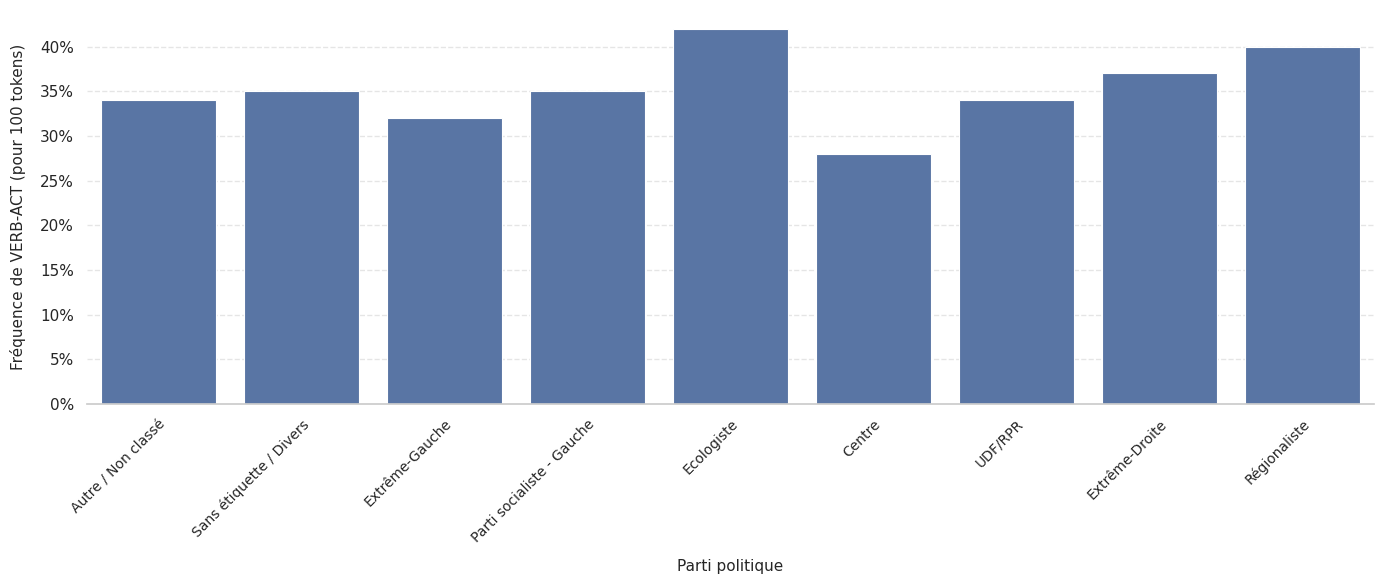

In [38]:
fig, ax = plt.subplots(figsize=(14, 6))

# Thème
sns.set_theme(style="whitegrid", font_scale=1)
palette = sns.color_palette("Blues_d", n_colors=len(stats2))


bars = sns.barplot(
    data = stats2,
    x = "parti_synthetique_",
    y = "freq_VERB_ACT",
    edgecolor = "white",
    linewidth = 0.8,
    ax = ax
)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))

ax.set_xlabel("Parti politique", fontsize=11, labelpad=10)
ax.set_ylabel("Fréquence de VERB-ACT (pour 100 tokens)", fontsize=11, labelpad=10)

# xticks bien placés et lisibles
ax.set_xticks(range(len(stats2)))
ax.set_xticklabels(
    stats2["parti_synthetique_"],
    rotation = 45,
    ha = "right",      # alignement à droite pour les labels tournés
    rotation_mode = "anchor",   # pivot sur le point d'ancrage → labels bien centrés sous les barres
    fontsize = 10
)

ax.yaxis.grid(True, linestyle="--", alpha=0.5)
ax.set_axisbelow(True)
ax.spines[["top", "right", "left"]].set_visible(False)

plt.tight_layout()
plt.show()

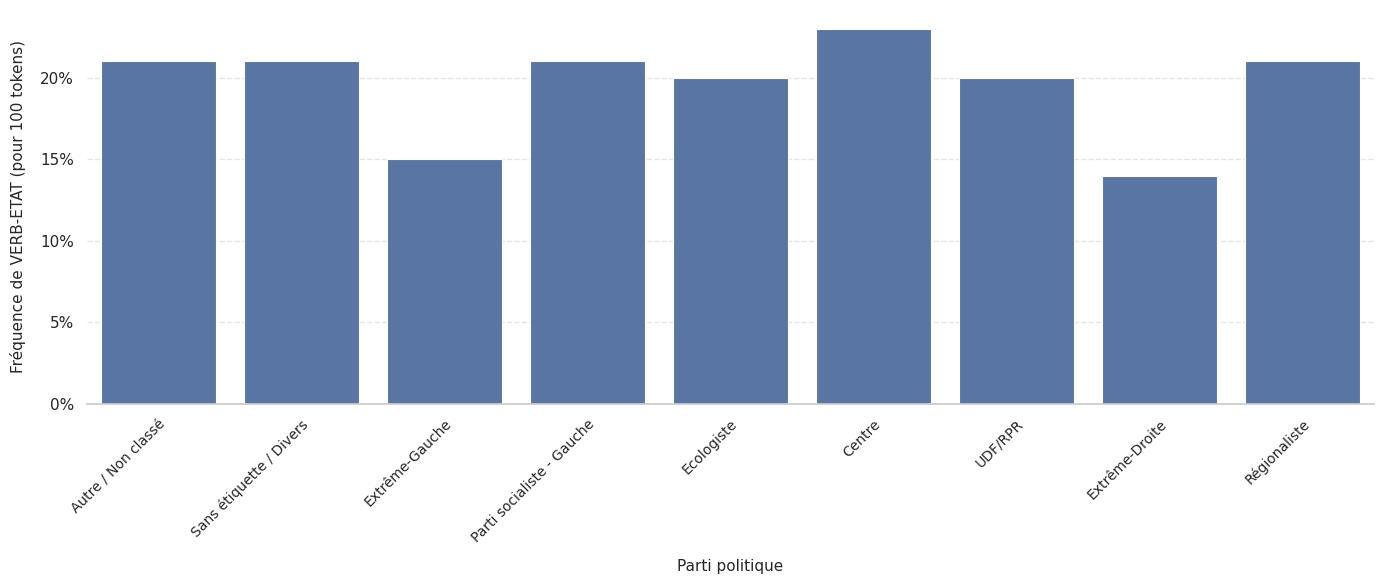

In [39]:
fig, ax = plt.subplots(figsize=(14, 6))

# Thème
sns.set_theme(style="whitegrid", font_scale=1)
palette = sns.color_palette("Blues_d", n_colors=len(stats2))


bars = sns.barplot(
    data = stats2,
    x = "parti_synthetique_",
    y = "freq_VERB_ETAT",
    edgecolor = "white",
    linewidth = 0.8,
    ax = ax
)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))

ax.set_xlabel("Parti politique", fontsize=11, labelpad=10)
ax.set_ylabel("Fréquence de VERB-ETAT (pour 100 tokens)", fontsize=11, labelpad=10)

# xticks bien placés et lisibles
ax.set_xticks(range(len(stats2)))
ax.set_xticklabels(
    stats2["parti_synthetique_"],
    rotation = 45,
    ha = "right",      # alignement à droite pour les labels tournés
    rotation_mode = "anchor",   # pivot sur le point d'ancrage → labels bien centrés sous les barres
    fontsize = 10
)

ax.yaxis.grid(True, linestyle="--", alpha=0.5)
ax.set_axisbelow(True)
ax.spines[["top", "right", "left"]].set_visible(False)

plt.tight_layout()
plt.show()

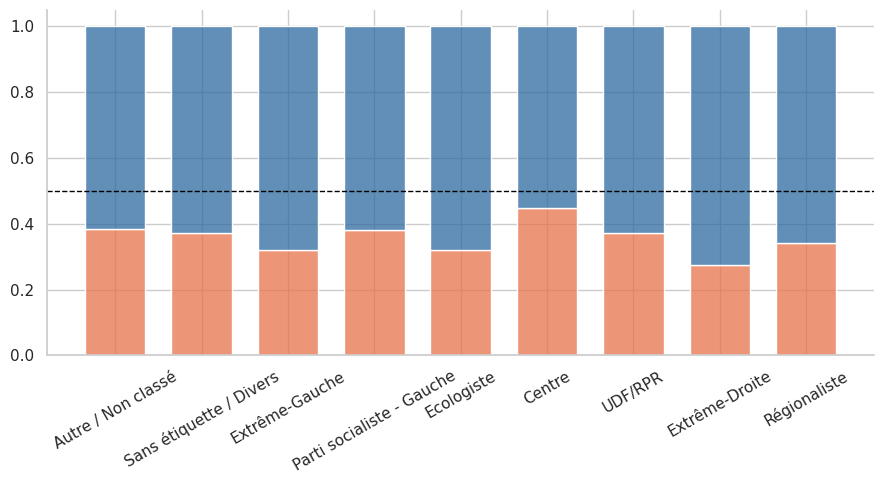

In [43]:
df_long2 = stats2.melt(
    id_vars="parti_synthetique_",
    value_vars=["part_VERB_ACT", "part_VERB_ETAT"],
    var_name="type_verbe",
    value_name="part",
)
 
# Barplot empilé
fig, ax = plt.subplots(figsize=(9, 5))
sns.histplot(
    data=df_long2,
    x="parti_synthetique_",
    weights="part",
    hue="type_verbe",
    multiple="stack",
    palette=["#2D6A9F", "#E8734A"],
    shrink=0.7,
    ax=ax,
    legend=False
)
ax.axhline(0.5, linestyle="--", color="black", linewidth=1)
ax.set(xlabel="", ylabel="", ylim=(0, 1.05))
ax.tick_params(axis="x", rotation=30)
sns.despine()
plt.tight_layout()

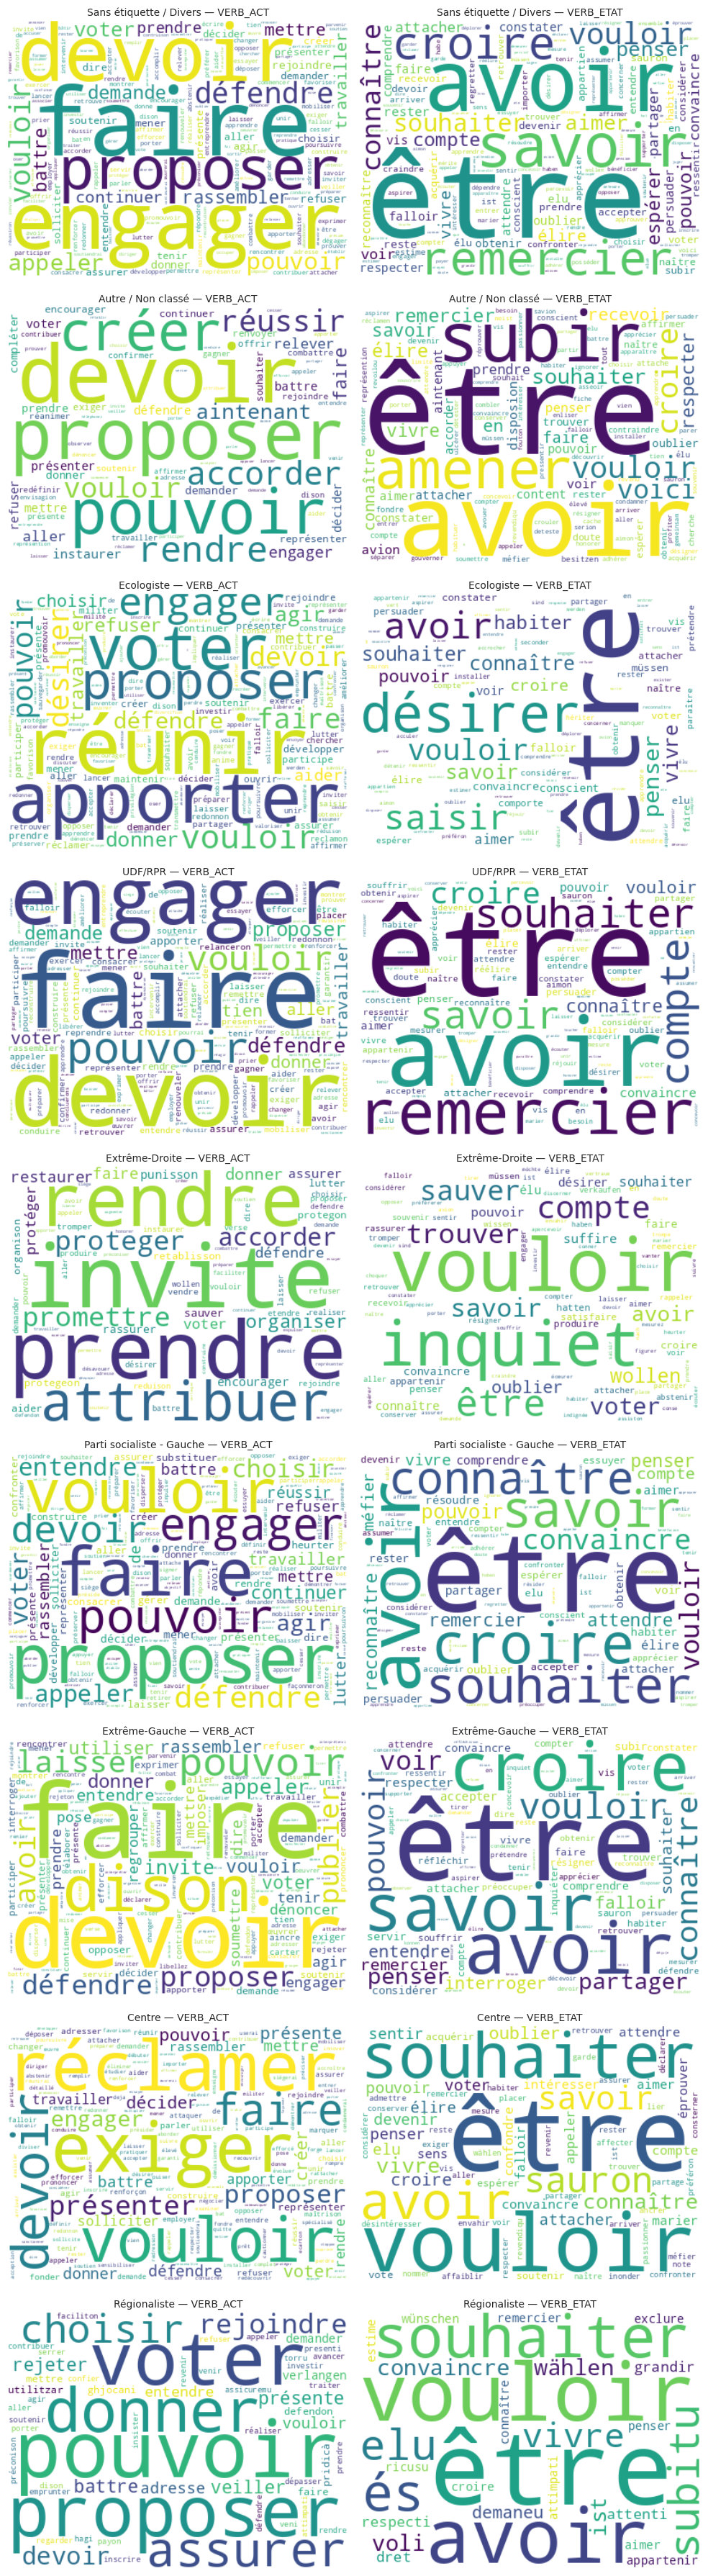

In [42]:
VB_LABELS = ["VERB_ACT", "VERB_ETAT"]
wordclouds_par_parti_et_categorie(textes_annotes_disc, VB_LABELS)